$$|0\rangle_L = \frac{(|000\rangle+|111\rangle)(|000\rangle+|111\rangle)(|000\rangle+|111\rangle)}{2\sqrt{2}}$$

$$|1\rangle_L = \frac{(|000\rangle-|111\rangle)(|000\rangle-|111\rangle)(|000\rangle-|111\rangle)}{2\sqrt{2}}$$

In [329]:
from dataclasses import dataclass
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer.primitives import SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from IPython.display import display

### Result Data Classes

In [ ]:
@dataclass
class SyndromeResult:
    """
    Output of a single syndrome measurement.

    Attributes
    ----------
    bits : np.ndarray, shape (8,)
        Raw syndrome bits ordered [g0, g1, ..., g7].
    x_errors : list[int]
        Data qubit indices identified as having X errors.
    z_errors : list[int]
        Data qubit indices identified as having Z errors.
    corrections : list[tuple[str, int]]
        List of (gate_type, qubit_index) corrections to apply.
        gate_type is 'X', 'Z', or 'XZ'.
    """
    bits        : np.ndarray
    x_errors    : list[int]
    z_errors    : list[int]
    corrections : list[tuple[str, int]]

    def __str__(self) -> str:
        bits_str = ''.join(str(b) for b in self.bits)
        return (
            f"Syndrome: {bits_str}\n"
            f"  X errors identified: {self.x_errors}\n"
            f"  Z errors identified: {self.z_errors}\n"
            f"  Corrections:         {self.corrections}"
        )


@dataclass
class CycleResult:
    """
    Output of a full encoding → error → syndrome measurement → correction cycle.

    Attributes
    ----------
    logical_input  : int - logical qubit state to be encoded
    error_type     : str - injected error ('X', 'Z', 'XZ', or None)
    error_qubit    : int - qubit the error was injected on (or None)
    syndrome       : SyndromeResult
    logical_output : int - logical qubit state after correction
    success        : bool - whether logical_output == logical_input
    """
    logical_input  : int
    error_type     : str | None
    error_qubit    : int | None
    syndrome       : SyndromeResult
    logical_output : int
    success        : bool

    def __str__(self) -> str:
        return (
            f"Logical input: {self.logical_input}\n"
            f"Error: {self.error_type} on qubit {self.error_qubit}\n"
            f"{self.syndrome}\n"
            f"Logical output: {self.logical_output}\n"
            f"Success: {'✓' if self.success else '✗'}"
        )

### Shor Code Class

In [ ]:
class ShorCode:
    """
    9-qubit Shor code implementation.

    Provides a full encoding, error injection, syndrome measurement and correction
    cycle for the 9-qubit Shor code using composable circuit-building methods.
    """

    N_DATA    : int = 9
    N_ANCILLA : int = 8

    # STABILISER DEFINITIONS

    # Z_STABILISER - tuple of two data qubits indices whose Z parity is measured by the corresponding ancilla.
    # Identifies bit-flip errors on specific qubits.
    Z_STABILISERS : list[tuple[int, int]] = [
        (0, 1),   # g0: Z0Z1 - block 0
        (1, 2),   # g1: Z1Z2 - block 0
        (3, 4),   # g2: Z3Z4 - block 1
        (4, 5),   # g3: Z4Z5 - block 1
        (6, 7),   # g4: Z6Z7 - block 2
        (7, 8),   # g5: Z7Z8 - block 2
    ]

    # X_STABILISER - list of data qubit indices whose X parity is measured by the corresponding ancilla.
    # Identifies a phase-flip error across a block.
    X_STABILISERS : list[list[int]] = [
        [0, 1, 2, 3, 4, 5],   # g6: X0X1X2X3X4X5
        [3, 4, 5, 6, 7, 8],   # g7: X3X4X5X6X7X8
    ]

    # SYNDROME LOOKUP TABLES

    # For a pair of Z stabilizers within one block:
    X_ERROR_LOOKUP : dict = {
        (0, 0): None,   # No X error in this block
        (1, 0): 0,      # X error on first qubit of block
        (1, 1): 1,      # X error on middle qubit of block
        (0, 1): 2,      # X error on last qubit of block
    }

    # For the two X stabilizers across the three blocks:
    Z_ERROR_LOOKUP : dict = {
        (0, 0): None,   # No Z error
        (1, 0): 0,      # Z error in block 0
        (1, 1): 1,      # Z error in block 1
        (0, 1): 2,      # Z error in block 2
    }

    BLOCK_STARTS : list[int] = [0, 3, 6]

    def __init__(self):
        self.simulator = AerSimulator() 

    # ENCODING

    def encoding_circuit(self) -> QuantumCircuit:
        """
        Return the 9-qubit Shor encoding circuit.

        Assumes qubit 0 initialised to input state α|0⟩ + β|1⟩.
        Qubits 1-8 initialised to |0⟩.

        Encoding steps
        --------------
        1 - Outer repetition code: 
            α|0⟩ + β|1⟩  →  α|+++⟩ + β|---⟩ 

        2 - Inner repetition code::
            |+⟩ → (|000⟩ + |111⟩)/√2
            |-⟩ → (|000⟩ - |111⟩)/√2

        Returns
        -------
        QuantumCircuit
            9-qubit circuit with no measurements.
        """
        qc = QuantumCircuit(self.N_DATA, name='encode')

        # 1 - Outer repetition code
        qc.cx(0, 3)
        qc.cx(0, 6)
        qc.h(0)
        qc.h(3)
        qc.h(6)

        # 2 - Inner repetition code 
        qc.cx(0, 1);  qc.cx(0, 2)   # block 0
        qc.cx(3, 4);  qc.cx(3, 5)   # block 1
        qc.cx(6, 7);  qc.cx(6, 8)   # block 2

        return qc

    def decoding_circuit(self) -> QuantumCircuit:
        """
        Return the inverse of the encoding circuit.

        After error correction, applying this maps the logical qubit
        back onto qubit 0.
        """
        return self.encoding_circuit().inverse()

    def prepare_logical(
        self,
        alpha: complex,
        beta:  complex,
    ) -> QuantumCircuit:
        """
        Prepare and encode α|0⟩ + β|1⟩ state.

        Parameters
        ----------
        alpha, beta : complex
            Amplitudes.
        
        Returns
        -------
        QuantumCircuit
            9-qubit circuit with the logical state encoded.
        """
        state = [alpha, beta]
        qc = QuantumCircuit(self.N_DATA)
        qc.initialize(state, 0)
        qc.compose(self.encoding_circuit(), inplace=True)
        return qc

    # ERROR INJECTION

    def inject_error(
        self,
        circuit    : QuantumCircuit,
        error_type : str,
        qubit      : int,
    ) -> QuantumCircuit:
        """
        Append a Pauli error to a specific data qubit.

        Parameters
        ----------
        circuit    : QuantumCircuit - encoded 9-qubit circuit.
        error_type : str - 'X', 'Z', or 'XZ'.
        qubit      : int - data qubit index (0-8).

        Returns
        -------
        QuantumCircuit
            Copy of the circuit with the error gate appended.

        """
        if not 0 <= qubit < self.N_DATA:
            raise ValueError(f"Qubit {qubit} out of range [0, {self.N_DATA-1}]")
        if error_type not in ('X', 'Z', 'XZ'):
            raise ValueError(f"error_type must be 'X', 'Z', or 'XZ'")

        qc = circuit.copy()
        if error_type == 'XZ':
            qc.x(qubit)
            qc.z(qubit)
        else:
            getattr(qc, error_type.lower())(qubit)
        return qc

    # SYNDROME MEASUREMENT

    def syndrome_circuit(
        self,
        data_circuit: QuantumCircuit,
    ) -> QuantumCircuit:
        """
        Builds the full syndrome measurement circuit.

        Appends 8 ancilla qubits and 8 classical syndrome bits to the
        data circuit. Ancillas connected to data qubits via a sequence of CNOTs 
        and Hadamards. Each ancilla is measured into syndrome register.

        Parameters
        ----------
        data_circuit : QuantumCircuit
            9-qubit encoded circuit (with error injected).

        Returns
        -------
        QuantumCircuit
            17-qubit circuit (9 data + 8 ancilla) with syndrome bits
            measured into classical syndrome register (8 bits).

        """
        qr_data = QuantumRegister(self.N_DATA, 'data')
        qr_anc = QuantumRegister(self.N_ANCILLA, 'ancilla')
        cr_syndrome = ClassicalRegister(self.N_ANCILLA, 'syndrome')

        qc = QuantumCircuit(qr_data, qr_anc, cr_syndrome)

        # Compose data circuit onto data qubits (indices 0-8)
        qc.compose(data_circuit, qubits=list(range(self.N_DATA)), inplace=True)
        qc.barrier()

        # Z_STABILISERS - ancillas 0-5 
        for anc_idx, (qi, qj) in enumerate(self.Z_STABILISERS):
            anc = self.N_DATA + anc_idx
            qc.cx(qi,  anc) # CNOT qi onto ancilla
            qc.cx(qj,  anc) # CNOT qj onto ancilla
            # ancilla = 0 if even parity, 1 if odd parity
        
        qc.barrier()

        # X_STABILISERS - ancillas 6-7
        for stab_idx, qubits in enumerate(self.X_STABILISERS):
            anc = self.N_DATA + len(self.Z_STABILISERS) + stab_idx
            qc.h(anc)  
            for q in qubits:
                qc.cx(anc, q) # CNOT each data qubit in stabiliser onto ancilla 
            qc.h(anc)  

        qc.barrier()

        # Measure all ancillas into classical syndrome register
        for anc_idx in range(self.N_ANCILLA):
            qc.measure(self.N_DATA + anc_idx, cr_syndrome[anc_idx])

        return qc

    def measure_syndrome(
        self,
        data_circuit: QuantumCircuit,
    ) -> tuple[np.ndarray, dict]:
        """
        Run the syndrome circuit and extract syndrome bits.

        Parameters
        ----------
        data_circuit : QuantumCircuit
            9-qubit encoded circuit with possible error injected.

        Returns
        -------
        syndrome_bits : np.ndarray 
            Bits ordered [g0, g1, ..., g7] matching stabiliser definitions.
        counts : dict
            Raw simulator measurement counts.

        Notes
        -----
        Qiskit returns classical bit strings in reverse qubit order, so 
        the rightmost character corresponds to classical bit 0. We reverse
        the string to recover [g0, ..., g7] ordering.

        """
        qc = self.syndrome_circuit(data_circuit)
        pm = generate_preset_pass_manager(3, self.simulator)
        qc_isa = pm.run(qc)
        sampler = Sampler(default_shots=1)
        job = sampler.run([qc_isa])
        outcome = list(job.result()[0].join_data().get_counts().keys())[0]    
        # Extract the syndrome bit string and reverse for correct ordering
        outcome = outcome[len(outcome)::-1]
        syndrome_bits = np.array([int(b) for b in outcome])
        return syndrome_bits, outcome
    
    # SYNDROME DECODING AND CORRECTION

    def syndrome_decode(self, syndrome_bits: np.ndarray) -> SyndromeResult:
        """
        Decode 8 syndrome bits into a set of Pauli corrections.

        Syndrome bit ordering & grouping:
            bit 0 - Z0Z1    
            bit 1 - Z1Z2  (X-error syndrome of block 0)
            -----------
            bit 2 - Z3Z4    
            bit 3 - Z4Z5  (X-error syndrome of block 1)
            -----------
            bit 4 - Z6Z7    
            bit 5 - Z7Z8  (X-error syndrome of block 2)
            ------------
            bit 6 - X0X1X2X3X4X5  
            bit 7 - X3X4X5X6X7X8  (Z-error syndrome across blocks)

        Correction logic
        --------------
        Bit-flip (X) errors:
            Each block's two X-error syndrome bits identify at most one X error
            using the X_ERROR_LOOKUP table. Each block decoded independently and 
            the code can correct one X error per block.

        Phase-flip (Z) errors:
            The two Z-error syndrome bits identify which block
            contains a Z error using Z_ERROR_LOOKUP. In which case a
            Z correction is applied to the first qubit of that block.
            Any qubit in the block works because a Z error anywhere 
            in a block flips the same logical parity.

        XZ errors:
            Corrected by combining the above.

        Parameters
        ----------
        syndrome_bits : np.ndarray, shape (8,)
            From measure_syndrome().

        Returns
        -------
        SyndromeResult
        """
        x_errors = []
        z_errors = []
        corrections = []

        # Decode X errors per block:
        for block_idx, block_start in enumerate(self.BLOCK_STARTS):
            s0 = int(syndrome_bits[2 * block_idx])
            s1 = int(syndrome_bits[2 * block_idx + 1])
            offset = self.X_ERROR_LOOKUP.get((s0, s1))

            if offset is not None:
                x_qubit = block_start + offset
                x_errors.append(x_qubit)
                corrections.append(('X', x_qubit))

        # Decode Z error across blocks:
        s6 = int(syndrome_bits[6])
        s7 = int(syndrome_bits[7])
        block = self.Z_ERROR_LOOKUP.get((s6, s7))

        if block is not None:
            z_qubit = self.BLOCK_STARTS[block]
            z_errors.append(z_qubit)
            corrections.append(('Z', z_qubit))
            
        return SyndromeResult(
            bits        = syndrome_bits,
            x_errors    = x_errors,
            z_errors    = z_errors,
            corrections = corrections,
        )

    # CORRECTION AND INVERSE ENCODING

    def correction_circuit(
        self,
        corrections: list[tuple[str, int]],
    ) -> QuantumCircuit:
        """
        Build a circuit applying a list of Pauli corrections.

        Parameters
        ----------
        corrections : list of (gate_type, qubit_index)
            From syndrome_decode().

        Returns
        -------
        QuantumCircuit
            9-qubit circuit. Empty if corrections is empty.
        """
        qc = QuantumCircuit(QuantumRegister(self.N_DATA), name='correct')
        for gate_type, qubit in corrections:
            getattr(qc, gate_type.lower())(qubit)
        return qc

    def inverse_encode_logical(
        self,
        corrected_circuit: QuantumCircuit,
    ) -> QuantumCircuit:
        """
        Apply inverse encoding to corrected circuit

        Reverse-encoding maps the logical qubit back to qubit 0.
       
        Parameters
        ----------
        corrected_circuit : QuantumCircuit
            9-qubit circuit after corrections have been applied.

        Returns
        -------
        QuantumCircuit
            Inverse encoding applied to corrected circuit. Qubit 0 
            should be in the original input state.
        """
        qc = QuantumCircuit(QuantumRegister(self.N_DATA))
        qc.compose(corrected_circuit, inplace=True)
        qc.compose(self.decoding_circuit(), inplace=True)
        return qc

## Shor Code Runthrough

1. Create instance of `ShorCode` class and set parameters for code test:

In [521]:
code = ShorCode()
error_type ='XZ'
error_qubit = 5
alpha = 1/np.sqrt(2)
beta = 1/np.sqrt(2)

2. Encode input state

In [522]:
circuit = code.prepare_logical(alpha, beta)
circuit.draw('mpl')
sv = Statevector.from_instruction(circuit)
display(sv.draw(output='latex'))

<IPython.core.display.Latex object>

3. Inject error

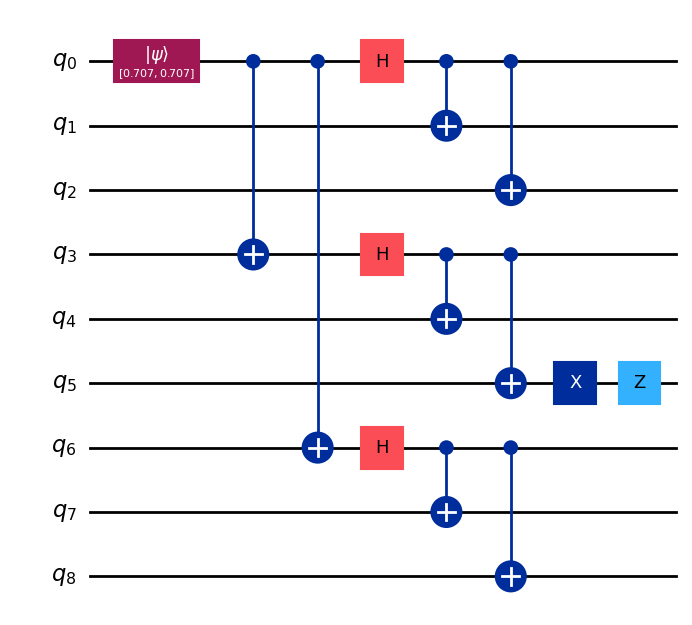

In [523]:
error_circuit = code.inject_error(circuit, error_type, error_qubit)
error_circuit.draw('mpl')

4. Measure syndrome

In [524]:
syndrome_circuit = code.syndrome_circuit(error_circuit)
syndrome_bits, _ = code.measure_syndrome(error_circuit)
print(f"Syndrome bits: {syndrome_bits}")

Syndrome bits: [0 0 0 1 0 0 1 1]


5. Error diagnosis

In [525]:
syndrome_result = code.syndrome_decode(syndrome_bits)
print(syndrome_result)

Syndrome: 00010011
  X errors identified: [5]
  Z errors identified: [3]
  Corrections:         [('X', 5), ('Z', 3)]


6. Apply appropriate corrections

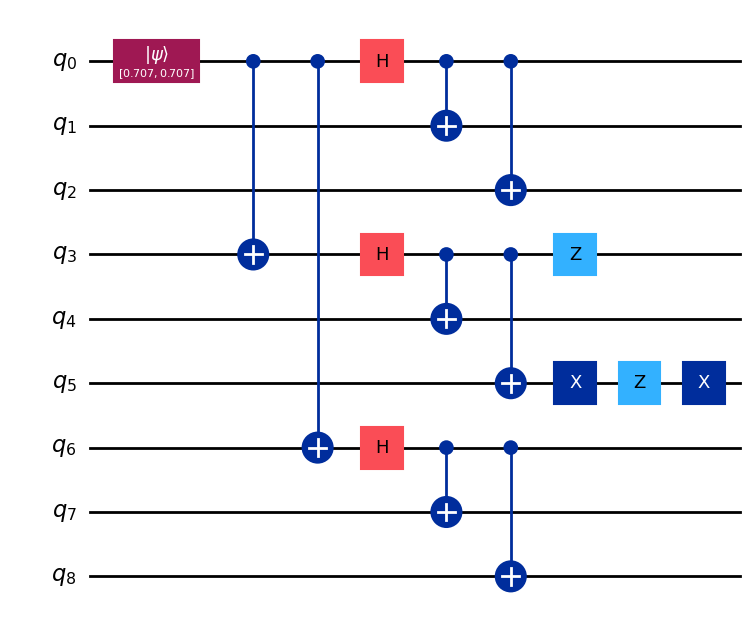

In [526]:
corrected = error_circuit.copy()
corrected.compose(code.correction_circuit(syndrome_result.corrections), inplace=True)
corrected.draw('mpl')

7. Apply reverse encoding and check qubit 0 is in original input state

Logical output state: [-0.70710678+0.j -0.70710678+0.j]


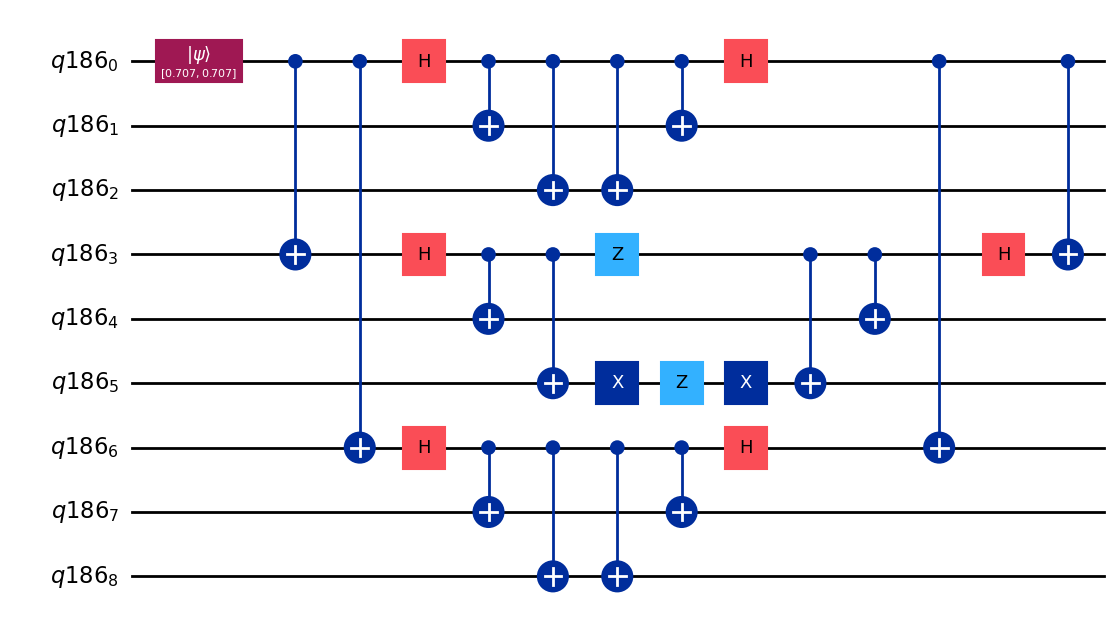

In [527]:
meas_qc = code.inverse_encode_logical(corrected)
logical_output = np.round(Statevector.from_instruction(meas_qc).data[0:2], 10)
print(f"Logical output state: {logical_output}")
meas_qc.draw('mpl')

Summaray of results

In [ ]:
res = CycleResult(
            logical_input = np.array([alpha, beta]),
            error_type = error_type,
            error_qubit = error_qubit,
            syndrome = syndrome_result,
            logical_output = logical_output,
            success = all(np.isclose(logical_output, np.array([alpha, beta]))) or 
            all(np.isclose(-logical_output, np.array([alpha, beta]))), # Final logical state may pick up global phase of -1
        )
print(res)

Logical input: [0.70710678 0.70710678]
Error: XZ on qubit 5
Syndrome: 00010011
  X errors identified: [5]
  Z errors identified: [3]
  Corrections:         [('X', 5), ('Z', 3)]
Logical output: [-0.70710678+0.j -0.70710678+0.j]
Success: ✓


In [529]:
from IPython.display import display, Math, Latex
qc = QuantumCircuit(1)
qc.initialize([1/np.sqrt(2),1/np.sqrt(2)], 0)
sv = Statevector.from_instruction(qc)
display(sv.draw(output="latex"))

<IPython.core.display.Latex object>